In [12]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from matplotlib_venn import venn3_circles
import seaborn as sns

from lifelines import CoxPHFitter
from lifelines import KaplanMeierFitter
import os 

import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [15]:
from Scripts.build_hazard_table import build_full_hazard_table, make_hazard_table 
from Scripts.cans_data_cleaning_pipeline import cans_pipeline


types = {
            'OptionsNumber': 'string',
            'DateCompleted': 'datetime64[ns]',
            'CANSCategoryName': 'string',
            'QuestionKey': 'string',
            'ItemTitle': 'string',
            'ChoiceValue': 'Int64'
             }
    
CANS_cols = ['OptionsNumber', 'DateCompleted', 'CANSCategoryName', 'QuestionKey', 'ItemTitle','ChoiceValue', 'AgeWhenAssessed', 'Gender', 'Ethnicity', 'PrimaryLanguage', 'County']
cat_cols = ['Gender', 'Ethnicity', 'PrimaryLanguage']
pre_demo_calls = ['AgeWhenAssessed', 'Gender', 'Ethnicity', 'PrimaryLanguage'] 
post_demo_columns = ["Black","Latino","No_Preference","Other","White","Spanish","M", 'AgeWhenAssessed']
    
       
folder_path = '/Users/daniellancet/Desktop/Spring_2026/CDSS_170/CANS_Project copy/Aspiranet_Data'
incident_category_path = '/Users/daniellancet/Desktop/Spring_2026/CDSS_170/CANS_Project copy/Novel_Data/UPDATED Incident Matching - Exact_Column_Name_Table.csv'



def read_dfs(folder_path): 

    if not os.path.exists(folder_path):
        print(f"Error: Folder '{folder_path}' not found. Please ensure it exists in your Google Drive.")
    else:
        data_files = [f for f in os.listdir(folder_path) if f.endswith('.xlsx')]

        if not data_files:
            print(f"No XLSX files found in '{folder_path}'.")
        else:
            
            print(f"Found {len(data_files)} data files. Loading...")
            dfs = {}
            for data_file in data_files:
                file_path = os.path.join(folder_path, data_file)
                try:
                    df = pd.read_excel(file_path)
                    
                    if 'CANS' in file_path: 
                        dfs['CANS'] = df 
                    if 'Incidents' in file_path: 
                        dfs['Incidents'] = df 
                    if 'Demographics' in file_path: 
                        dfs['Demographics'] = df 
            
                except Exception as e:
                    print(f"Error loading {data_file}: {e}")

            return dfs
        
def get_full_hazard(dfs, incident_category_path = incident_category_path, filter_amount = 200):
    incident_categories = pd.read_csv(incident_category_path)
    cans_cleaned = dfs['CLEANED_CANS'] 
    incidents_df = dfs['Incidents']
        
    def incident_cat_cols(incident_category, incident_path = incident_category_path): 
        df = pd.read_csv(incident_path) 
        return df[incident_category].dropna().values

    suicide_related_incidents = incident_cat_cols('Suicide Related Incidents', incident_path= incident_category_path)

    base_hazard_table = make_hazard_table(cans_df=cans_cleaned, incidents_df=incidents_df, incident_list=suicide_related_incidents, filter_amount=filter_amount) # could be any incident list
    incident_cat_dict = {inc_cat.replace('/', '_').replace(' ', '_').replace('__', '_'): incident_cat_cols(incident_category=inc_cat, incident_path = incident_category_path) for inc_cat in incident_categories.columns}
    incident_cols = [
    'event_date',
    'event',
    'stop_days',
    'days_since_last_incident'
    ]
    keep_cols = [c for c in base_hazard_table.columns if c not in incident_cols]
    base_table = base_hazard_table[keep_cols]
    full_hazard_table = build_full_hazard_table(incident_cat_dict, cans_df=cans_cleaned, incidents_df=incidents_df, base_table = base_table, filter_interval=False)


    return full_hazard_table
        


def build_new_dfs(dfs, types = types, CANS_cols = CANS_cols, cat_cols = cat_cols, pre_demo_calls = pre_demo_calls, lowest_n_cols = 45, filter_amount = 2000): 
    cans = dfs['CANS'] 

    category_mapping = cans.groupby('ItemTitle')['CANSCategoryName'].unique().to_dict()
    item_title_mapping = {k: v[0] for k, v in category_mapping.items()}
    cleaned_cans, lowest_n_cols = cans_pipeline(cans_scores=cans, cols=CANS_cols, types = types, cat_cols= cat_cols,top_n_lowest=lowest_n_cols, pre_demo_cols=pre_demo_calls, item_title_mapping = item_title_mapping);

    dfs['CLEANED_CANS'] = cleaned_cans
    full_hazard_table = get_full_hazard(dfs, filter_amount=filter_amount)
    dfs['FULL_HAZARD_TABLE'] = full_hazard_table 

    return dfs, lowest_n_cols 
   


data_df = read_dfs(folder_path)
dfs, top_n_cols = build_new_dfs(data_df)

Found 3 data files. Loading...
Duplicates Removed: 2836
Excluded 591 rows: invalid QuestionKey, missing ChoiceValue, or non-max ChoiceValue within group
1. Initial top_n count: 45
2. Count after removing Index columns: 43
3. Degenerate rows excluded: 48
5. All features have variance.


2 years from first observation

In [16]:
cans_cleaned = pd.read_csv('/Users/daniellancet/Desktop/Spring_2026/CANS_Project/OneDrive_2_2-7-2026/cans_demo_data.csv', dtype={'OptionsNumber': str}) 
incidents = pd.read_excel('//Users/daniellancet/Desktop/Spring_2026/CANS_Project/OneDrive_2_2-7-2026/Incidents Jan 1 2020 to  Dec 31 2025 Demographic Information Revised With County of Service.xlsx', dtype = 'str')
cat_list = ["12. Suicide Talk - screening", "14. Suicide Talk resulting in Hospitalization", "18. Self-Harm", "17. Suicide Attempt resulting in Hospitalization", "19. Self-Harm resulting in Outside Intervention", "16. Suicide Attempt resulting in outside intervent", "15. Suicide Attempt - Screening"]
cans_incidents = incidents[incidents['OptionsNumber'].isin(cans_cleaned['OptionsNumber'])]

#incidents['OptionsNumber'].isin(cans_cleaned['OptionsNumber']).sum()

suicide_related_incidents = cans_incidents[cans_incidents['IncidentType'].isin(cat_list)]
suicide_table = suicide_related_incidents[['OptionsNumber', 'IncidentDate', 'IncidentType']]

cans_cols = [
    'Substance Use','Sleep','Decision Making/Judgment','Family Function','Anxiety',
    'Adjustment To Trauma','Social Functioning','Living Situation',
    'Oppositional','Depression','Sexual Development','Conduct',
    'Impulsivity/Hyperactivity','Developmental/Intellectual','Anger Control',
    'Psychosis','School Attendance','School Behavior','School Achievement',
    'Intentional Misbehavior/Social Behavior','Other Self Harm (Recklessness)',
    'Non-Suicidal Self Injurious Behavior','Danger To Others','Suicide Risk',
    'Sexual Aggression','Runaway','Educational','Family Strengths','Talents/Interests',
    'Natural Supports','Delinquent Behavior','Interpersonal','Community Life/Connection',
    'Spiritual/Religious','Knowledge','Involvement With Care','Social Resources',
    'Supervision','Medical/Physical Health','Developmental','Mental Health',
    'Residential Stability','Safety'
]

# Build Hazards Table


In [17]:


def make_hazard_table(cans_df, incidents_df, incident_list,
                      admin_censor_date="2025-12-31", max_gap_days=180, filter_interval= True, filter_amount = 200):
    """
    Construct a hazard table for survival analysis suitable for lifelines CoxPHFitter.
    Durations are numeric floats (days since first assessment per person).
    
    Parameters
    ----------
    cans_df : pd.DataFrame
        CANS assessment data with at least ['OptionsNumber', 'DateCompleted'].
    incidents_df : pd.DataFrame
        Incident data with ['OptionsNumber', 'IncidentType', 'IncidentDate'].
    incident_list : list of str
        Incident types to include as the "event".
    admin_censor_date : str or pd.Timestamp
        Administrative censor date (used to fill last assessment interval).
    max_gap_days : int
        Maximum days allowed between assessments before considering censoring.
    
    Returns
    -------
    pd.DataFrame
        Hazard-table-ready DataFrame with numeric durations and binary events:
        ['OptionsNumber', 'DateCompleted', 'start', 'stop', 'start_days', 'stop_days',
         'event', 'days_since_last_assessment', 'days_since_last_incident']
    """
    

    incidents_sub = incidents_df[incidents_df['IncidentType'].isin(incident_list)].copy()
    incidents_sub['IncidentDate'] = pd.to_datetime(incidents_sub['IncidentDate'])
    incident_dict = incidents_sub.groupby('OptionsNumber')['IncidentDate'].apply(list).to_dict()
    
    cans = cans_df.copy()
    cans['DateCompleted'] = pd.to_datetime(cans['DateCompleted'])
    cans = cans.sort_values(['OptionsNumber', 'DateCompleted'])
    
    cans['Next_Assessment'] = cans.groupby('OptionsNumber')['DateCompleted'].shift(-1)
    
    admin_censor_date = pd.Timestamp(admin_censor_date)
    max_followup = cans['DateCompleted'] + pd.Timedelta(days=max_gap_days)
    
    cans['Next_Assessment'] = cans['Next_Assessment'].fillna(
        pd.Series(np.minimum(max_followup.values.astype('int64'), admin_censor_date.value))
        .astype('datetime64[ns]')
    )
    
    cans['start'] = cans['DateCompleted']
    cans['stop']  = cans['Next_Assessment']

    def get_event(row):
        """Return first incident date in interval and binary event."""
        incidents = incident_dict.get(row['OptionsNumber'], [])
        interval_incidents = [d for d in incidents if row['start'] < d <= row['stop']]
        if not interval_incidents:
            return pd.Series([pd.NaT, 0])
        return pd.Series([min(interval_incidents), 1])
    
    cans[['event_date', 'event']] = cans.apply(get_event, axis=1)

    origin = cans.groupby('OptionsNumber')['start'].transform('min')
    cans['start_days'] = (cans['start'] - origin).dt.total_seconds() / 86400
    cans['stop_days']  = (cans['event_date'].fillna(cans['stop']) - origin).dt.total_seconds() / 86400
    
    cans['start_days'] = cans['start_days'].astype(float)
    cans['stop_days']  = cans['stop_days'].astype(float)
    cans['event']      = cans['event'].astype(int)
    
    cans['days_since_last_assessment'] = cans.groupby('OptionsNumber')['DateCompleted']\
                                             .diff().dt.days.fillna(0)
    
    def days_since_last_incident(row):
        incidents = incident_dict.get(row['OptionsNumber'], [])
        past_incidents = [d for d in incidents if d <= row['start']]
        if len(past_incidents) == 0:
            return np.nan
        return (row['start'] - past_incidents[-1]).days
    
    cans['days_since_last_incident'] = cans.apply(days_since_last_incident, axis=1)

    hazard_table = cans

    if filter_interval:
        hazard_table = hazard_table[hazard_table['stop_days'] - hazard_table['start_days'] <= filter_amount]
    
    return hazard_table

hazard_table = make_hazard_table(cans_df=cans_cleaned, incidents_df=incidents, incident_list=cat_list)
hazard_table

,OptionsNumber,DateCompleted,Substance Use,Sleep,Decision Making/Judgment,Family Function,Anxiety,Adjustment To Trauma,Social Functioning,Living Situation,...,M,Next_Assessment,start,stop,event_date,event,start_days,stop_days,days_since_last_assessment,days_since_last_incident
0,20034,2022-12-08,1.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,...,1,2023-03-08,2022-12-08,2023-03-08,NaT,0,0.0,90.0,0.0,NaN
1,20034,2023-03-08,1.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,...,1,2023-06-07,2023-03-08,2023-06-07,NaT,0,90.0,181.0,90.0,NaN
2,20034,2023-06-07,1.0,0.0,2.0,3.0,1.0,1.0,1.0,2.0,...,1,2023-07-19,2023-06-07,2023-07-19,NaT,0,181.0,223.0,91.0,NaN
3,20034,2023-07-19,1.0,0.0,2.0,3.0,1.0,1.0,1.0,2.0,...,1,2024-01-15,2023-07-19,2024-01-15,NaT,0,223.0,403.0,42.0,NaN
4,20035,2022-12-21,0.0,0.0,3.0,1.0,0.0,2.0,2.0,1.0,...,1,2023-03-21,2022-12-21,2023-03-21,NaT,0,0.0,90.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3376,96369,2025-12-08,0.0,0.0,2.0,2.0,2.0,0.0,2.0,2.0,...,1,2025-12-31,2025-12-08,2025-12-31,NaT,0,91.0,114.0,91.0,NaN
3377,96524,2025-09-03,1.5,2.0,2.0,2.0,0.0,1.0,1.0,2.0,...,0,2025-12-31,2025-09-03,2025-12-31,NaT,0,0.0,119.0,0.0,NaN
3378,96823,2025-10-03,0.5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1,2025-12-31,2025-10-03,2025-12-31,NaT,0,0.0,89.0,0.0,NaN
3379,97089,2025-10-21,0.0,1.0,2.0,3.0,2.0,0.0,2.0,0.0,...,0,2025-12-31,2025-10-21,2025-12-31,NaT,0,0.0,71.0,0.0,NaN


# Fit Cox Proportional Hazards Model

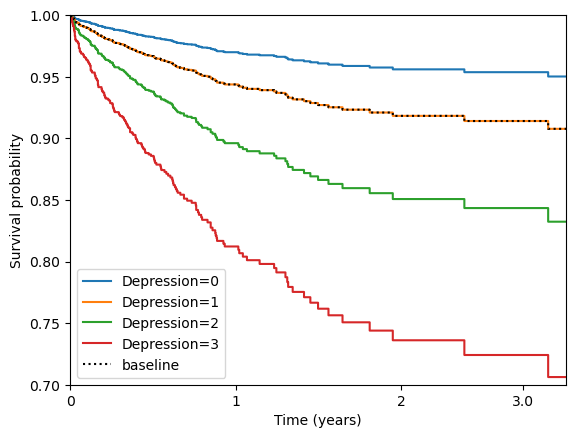

In [18]:



lst = ['stop_days', 'start_days', 'OptionsNumber', 'event', 'Depression', 'Anxiety', 'Social Functioning']
hazard_table_plt = hazard_table
#lst = hazard_table_plt.columns

#lst = ['stop_days', 'start_days', 'OptionsNumber', 'event'] + cans_cols
hazard_table_plt = hazard_table[lst] 
cph = CoxPHFitter() 
cph.fit( hazard_table_plt, 
        duration_col='stop_days', 
        event_col='event', 
        entry_col='start_days', 
        cluster_col='OptionsNumber' ) 

# import matplotlib.pyplot as plt

# import matplotlib.pyplot as plt

# Plot survival curves for Depression values 0–3
ax = cph.plot_covariate_groups('Depression', values=[0, 1, 2, 3])

# Restrict x-axis to first 1000 days
ax.set_xlim(0, 365*3)

# Convert x-axis from days to years
ax.set_xticks([0, 365, 730, 1000])           # positions in days
ax.set_xticklabels([0, 1, 2, round(365*3/365,1)])  # labels in years

# Optional: restrict y-axis
ax.set_ylim(0.70, 1)

# Label axes
ax.set_xlabel("Time (years)")
ax.set_ylabel("Survival probability")

plt.show()


In [ ]:
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter

def subsample_l1_selection_individuals(df, duration_col, event_col, entry_col=None, cluster_col='OptionsNumber',
                                      covariates=None, n_subsamples=50, sample_frac=0.7, penalizer=0.01,
                                      l1_ratio=0.5, selection_threshold=0.6, random_state=42, threshold = 0.01):
    """
    Subsampling-based L1/elastic-net feature selection for CoxPH, sampling individuals.
    Returns covariates selected based on frequency across subsamples.
    """
    np.random.seed(random_state)
    covariates = covariates if covariates is not None else df.columns.tolist()
    covariates = [c for c in covariates if c not in [duration_col, event_col, entry_col, cluster_col]]
    
    selection_counts = pd.Series(0, index=covariates)
    unique_ids = df[cluster_col].unique()
    
    for i in range(n_subsamples):
        sampled_ids = np.random.choice(unique_ids, size=int(len(unique_ids)*sample_frac), replace=False)
        subsample = df[df[cluster_col].isin(sampled_ids)]
        
        cph = CoxPHFitter(penalizer=penalizer, l1_ratio=l1_ratio)
        try:
            cph.fit(subsample[[duration_col, event_col] + covariates + ([entry_col] if entry_col else []) + ([cluster_col] if cluster_col else [])],
                    duration_col=duration_col,
                    event_col=event_col,
                    entry_col=entry_col,
                    cluster_col=cluster_col,
                    show_progress=False)
        except Exception as e:
            print(f"Subsample {i} failed: {e}")
            continue

        nonzero_covs = cph.params_.loc[covariates][cph.params_.loc[covariates].abs() > threshold].index.tolist()
        selection_counts[nonzero_covs] += 1
    
    selection_freq = selection_counts / n_subsamples
    selected_vars = selection_freq[selection_freq >= selection_threshold].sort_values(ascending=False)
    
    return selected_vars

# -----------------------------
# Example call on your dataset
# -----------------------------

# Assume `cans_cols` is your list of CANS covariates
# Make the full covariate list
covariates = cans_cols  

selected_features = subsample_l1_selection_individuals(
    df=hazard_table,
    duration_col='stop_days',
    event_col='event',
    entry_col='start_days',
    cluster_col='OptionsNumber',
    covariates=covariates,
    n_subsamples=100,
    sample_frac=0.7,
    penalizer=0.005,   # slightly lighter penalization
    l1_ratio=0.6,       # still elastic net, less aggressive
    selection_threshold=0.6,  # include features appearing in ≥50% subsamples
    threshold=0.01      # lower small-coefficient cutoff
)
print("Features selected by subsampling L1:")
print(selected_features, print(len(selected_features)))

In [ ]:
# results = cph.summary
# results['coef_magnitude'] = np.abs(cph.summary['coef'])
# results = results.sort_values(by = 'coef_magnitude', ascending=False)


hazard_table_l1 = hazard_table[['stop_days', 'start_days', 'OptionsNumber', 'event']  + list(selected_features.index)]    #.summary['coef']#.sort_values(ascending = False)[]

cph_2 = CoxPHFitter() 
cph_2.fit(hazard_table_l1, 
        duration_col='stop_days', 
        event_col='event', 
        entry_col='start_days', 
        cluster_col='OptionsNumber' ) 
res_2 = cph_2.summary.sort_values(by = 'p').reset_index()
res_2['p < 0.05'] = res_2['p'] < 0.05

res_2


,covariate,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p),p < 0.05
0,Suicide Risk,0.875120,2.399162,0.131657,0.617078,1.133162,1.853503,3.105459,0.0,6.646991,2.991461e-11,34.960359,True
1,Residential Stability,-0.435211,0.647128,0.139435,-0.708499,-0.161923,0.492383,0.850507,0.0,-3.121239,1.800917e-03,9.117053,True
2,Social Functioning,-0.324184,0.723118,0.111538,-0.542793,-0.105574,0.581123,0.899808,0.0,-2.906497,3.655006e-03,8.095910,True
3,Impulsivity/Hyperactivity,0.247070,1.280269,0.101670,0.047801,0.446340,1.048962,1.562582,0.0,2.430124,1.509367e-02,6.049913,True
4,Social Resources,0.271475,1.311898,0.115670,0.044766,0.498185,1.045783,1.645732,0.0,2.346973,1.892660e-02,5.723441,True
5,Developmental,0.422426,1.525659,0.183978,0.061835,0.783017,1.063787,2.188064,0.0,2.296065,2.167215e-02,5.528014,True
6,Delinquent Behavior,-0.322141,0.724596,0.158814,-0.633411,-0.010872,0.530778,0.989187,0.0,-2.028419,4.251753e-02,4.555798,True
7,Oppositional,-0.213854,0.807466,0.112443,-0.434238,0.006530,0.647758,1.006552,0.0,-1.901888,5.718586e-02,4.128198,False
8,Family Strengths,0.174026,1.190087,0.098950,-0.019913,0.367965,0.980284,1.444792,0.0,1.758723,7.862457e-02,3.668876,False
9,Depression,0.206871,1.229824,0.122006,-0.032256,0.445997,0.968259,1.562047,0.0,1.695584,8.996465e-02,3.474498,False


In [ ]:
baseline = cph.baseline_cumulative_hazard_
H0_90 = baseline.loc[90].values[0]

beta = 0.633401

p0 = 1 - np.exp(-H0_90)
p1 = 1 - np.exp(-H0_90 * np.exp(beta))
p0, p1

2.318247e-01	

0.2318247

# Check Proportional Hazards Assumption

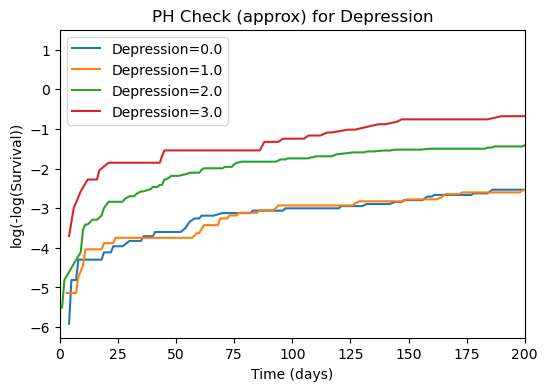

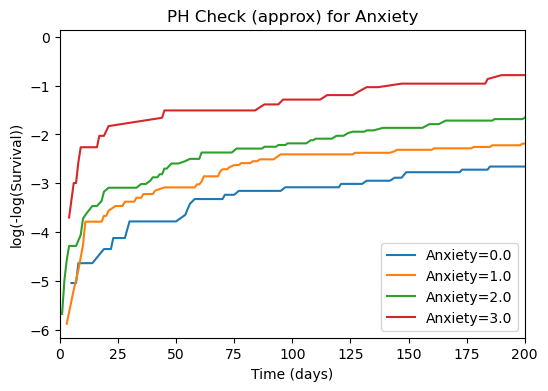

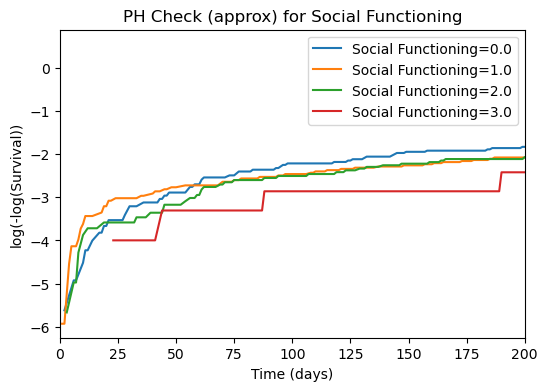

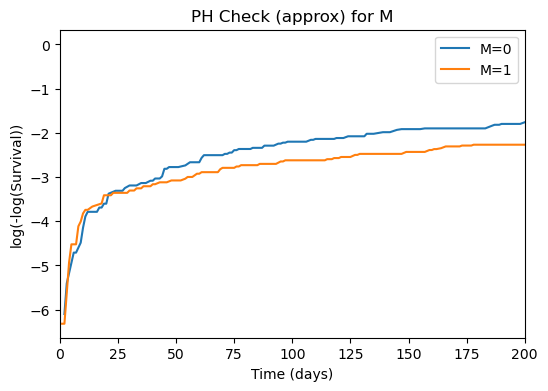

In [ ]:


def plot_ph_check(hazard_table, covariates, duration_col='stop_days', event_col='event', entry_col='start_days', max_time = 200):
    """
    Approximate PH assumption check for left-truncated data.
    Uses log(-log(survival)) curves by covariate level.
    Restricts plot to actual observed time range.
    """
    kmf = KaplanMeierFitter()
    max_time = max_time  

    for cov in covariates:
        plt.figure(figsize=(6,4))
        for val in sorted(hazard_table[cov].dropna().unique()):
            mask = hazard_table[cov] == val
            df_sub = hazard_table[mask]
            kmf.fit(df_sub[duration_col],
                    event_observed=df_sub[event_col],
                    entry=df_sub[entry_col],
                    label=f"{cov}={val}")
            surv = kmf.survival_function_
            # Filter out 0 or 1 survival to avoid -inf/inf
            surv = surv[(surv[f"{cov}={val}"] > 0) & (surv[f"{cov}={val}"] < 1)]
            with np.errstate(divide='ignore'):
                loglog_surv = np.log(-np.log(surv))
            plt.plot(loglog_surv.index, loglog_surv.values, label=f"{cov}={val}")

        plt.xlabel("Time (days)")
        plt.ylabel("log(-log(Survival))")
        plt.title(f"PH Check (approx) for {cov}")
        plt.xlim(0, max_time)
        plt.legend()
        plt.show()


covariates = ['Depression', 'Anxiety', 'Social Functioning', 'M']


plot_ph_check(
    hazard_table,
    covariates=covariates,
    duration_col='stop_days',
    event_col='event',
    entry_col='start_days'
)
        

# Risk Function By CANS Score

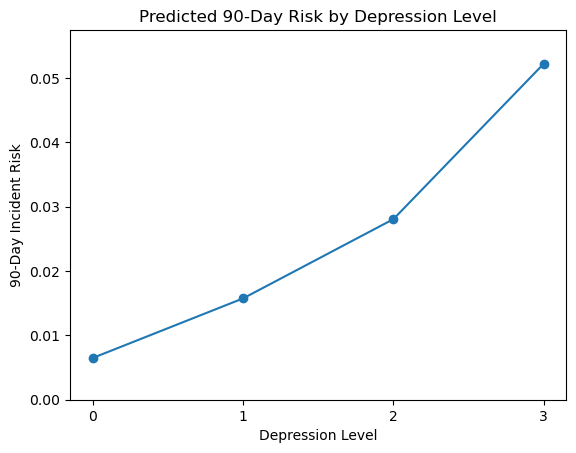

In [ ]:
# Profiles: vary Depression, hold others fixed
profiles = pd.DataFrame({
    'Depression': [0, 1, 2, 3],
    'Anxiety': [0, 1, 1, 1],
    'Social Functioning': [2, 2, 2, 2],
    'M': [0, 0, 1, 1]
})

# Predict survival exactly at 90 days
surv_90 = cph.predict_survival_function(profiles, times=[90])

# Convert to 90-day risk
risk_90 = 1 - surv_90.loc[90]

# Single plot: 90-day risk by Depression level
plt.figure()
plt.plot(profiles['Depression'], risk_90.values, marker='o')

plt.xlabel("Depression Level")
plt.ylabel("90-Day Incident Risk")
plt.title("Predicted 90-Day Risk by Depression Level")
plt.xticks(profiles['Depression'])
plt.ylim(0, max(risk_90.values) * 1.1);


# Risk By Profile

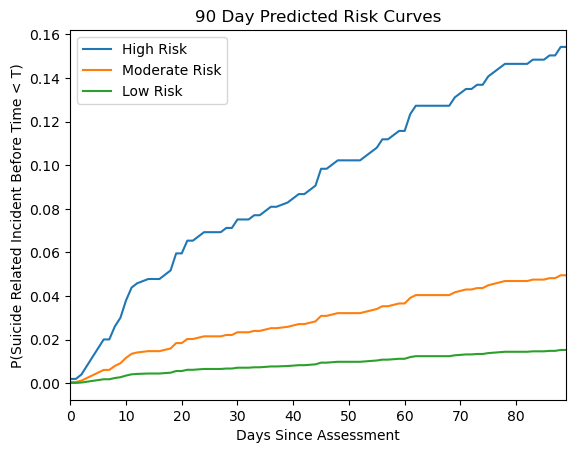

90-Day Risks:
High Risk        0.154220
Moderate Risk    0.049541
Low Risk         0.015295
Name: 89.0, dtype: float64


In [ ]:
# Three profiles
profiles = pd.DataFrame({
    'Depression': [3, 2, 1],              # High, Moderate, Low
    'Anxiety': [3, 2, 1],
    'Social Functioning': [0, 1, 2]       # Low, Moderate, High
}, index=["High Risk", "Moderate Risk", "Low Risk"])

# 0–90 day time grid
time_grid = np.arange(0, 90)

# Predict survival
surv = cph.predict_survival_function(profiles, times=time_grid)

# Convert to cumulative risk
risk = 1 - surv

# Plot
plt.figure()

for i, label in enumerate(profiles.index):
    plt.plot(risk.index, risk.iloc[:, i], label=label)

plt.xlabel("Days Since Assessment")
plt.ylabel("P(Suicide Related Incident Before Time < T)")
plt.title("90 Day Predicted Risk Curves")
plt.xlim(0, 89)
plt.legend()
plt.show()


print("90-Day Risks:")
print(risk.loc[89]);


